In [1]:
!wget -q --show-progress https://www.kaggle.com/api/v1/datasets/download/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign -O gtsrb.zip

gtsrb.zip           100%[===================>] 611.85M  16.2MB/s    in 7.4s    


In [2]:
!unzip -q gtsrb.zip -d /content/data

In [4]:
import os

TRAIN_DIR = "/content/data/Train"
TEST_DIR = "/content/data/Test"
TEST_CSV = "/content/data/Test.csv"

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))
print("Test.csv exists:", os.path.exists(TEST_CSV))

print("\nNumber of train classes:", len(os.listdir(TRAIN_DIR)))
print("Classes:", sorted(os.listdir(TRAIN_DIR), key=int))

Train exists: True
Test exists: True
Test.csv exists: True

Number of train classes: 43
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42']


In [5]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

BATCH_SIZE=32
IMG_SIZE=(48,48)

train_ds=image_dataset_from_directory(
    TRAIN_DIR,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=42,
    label_mode='int'
)

class_names=train_ds.class_names
print("Class names:", class_names)
print("length", len(class_names))

Found 39209 files belonging to 43 classes.
Class names: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']
length 43


In [6]:
images, labels = next(iter(train_ds))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10].numpy())

Images shape: (32, 48, 48, 3)
Labels shape: (32,)
Labels: [ 8 12  4  4 27 32 19  3 29 13]


In [8]:
import pandas as pd

TEST_CSV = "/content/data/Test.csv"

test_df = pd.read_csv(TEST_CSV)

print(test_df.head())
print("\nColumns:")
print(test_df.columns.tolist())

print("\nShape:", test_df.shape)

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png

Columns:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']

Shape: (12630, 8)


In [9]:
import os
import numpy as np
from PIL import Image

TEST_DIR = "/content/data/Test"
IMG_SIZE = (48, 48)

test_images = []
test_labels = []

for _, row in test_df.iterrows():
    image_path = os.path.join("/content/data", row["Path"])

    image = Image.open(image_path).convert("RGB")
    image = image.resize(IMG_SIZE)

    test_images.append(np.array(image))
    test_labels.append(row["ClassId"])

X_test = np.array(test_images)
y_test = np.array(test_labels)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (12630, 48, 48, 3)
y_test shape: (12630,)


In [10]:
print("Pixel range:", X_test.min(), "to", X_test.max())
print("Number of test samples:", len(X_test))
print("Number of classes:", len(np.unique(y_test)))
print("Classes:", np.unique(y_test))

Pixel range: 0 to 255
Number of test samples: 12630
Number of classes: 43
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


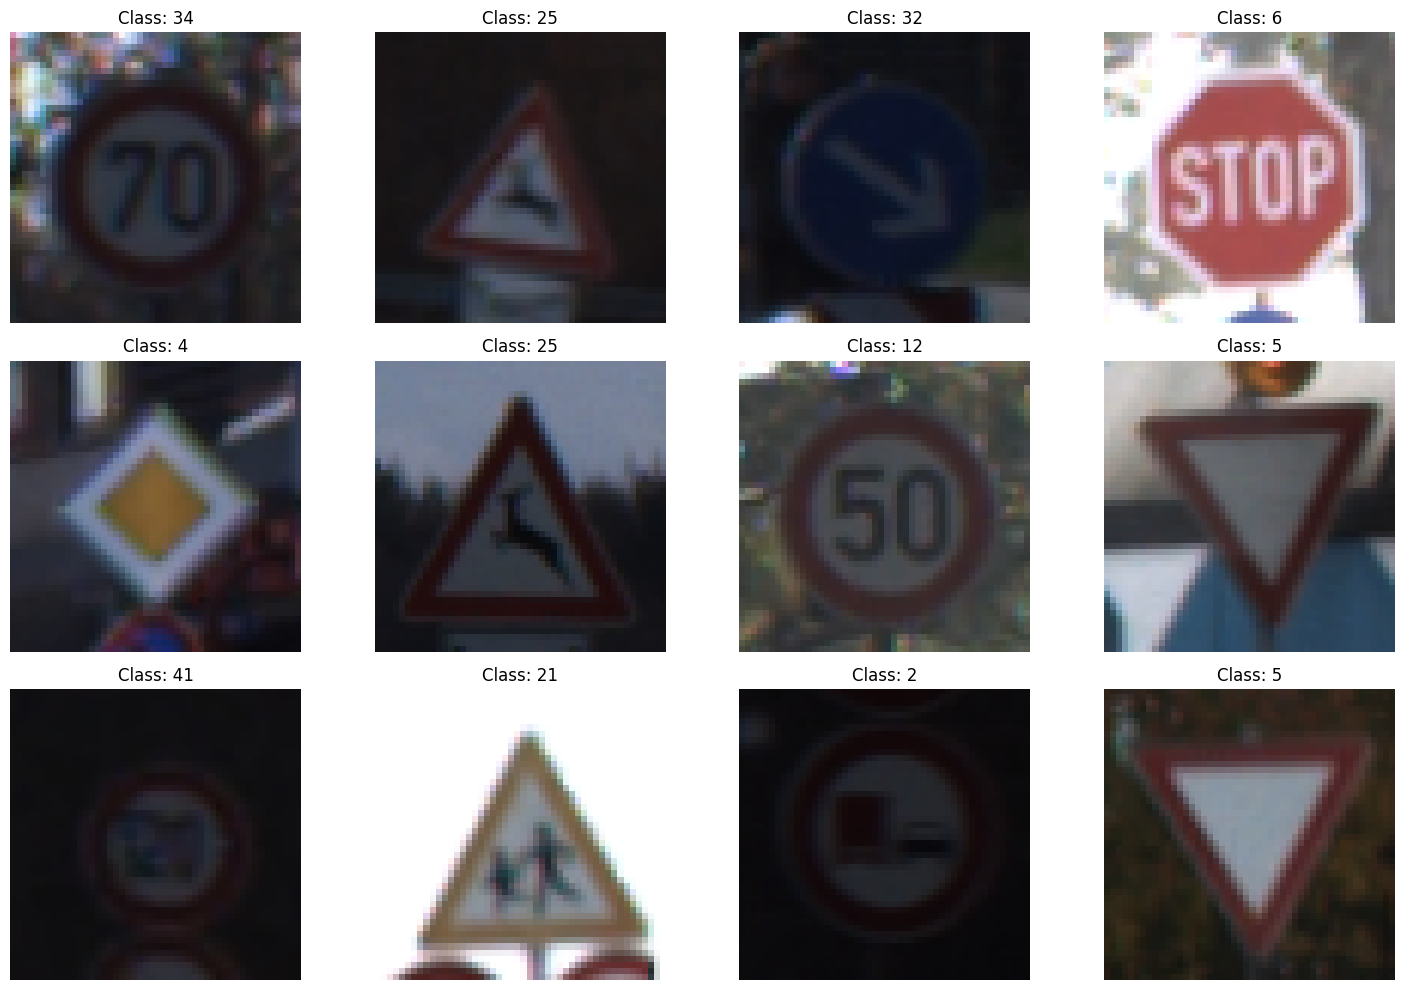

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for i in range(12):
    image = images[i].numpy().astype("uint8")
    label = labels[i].numpy()

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(f"Class: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

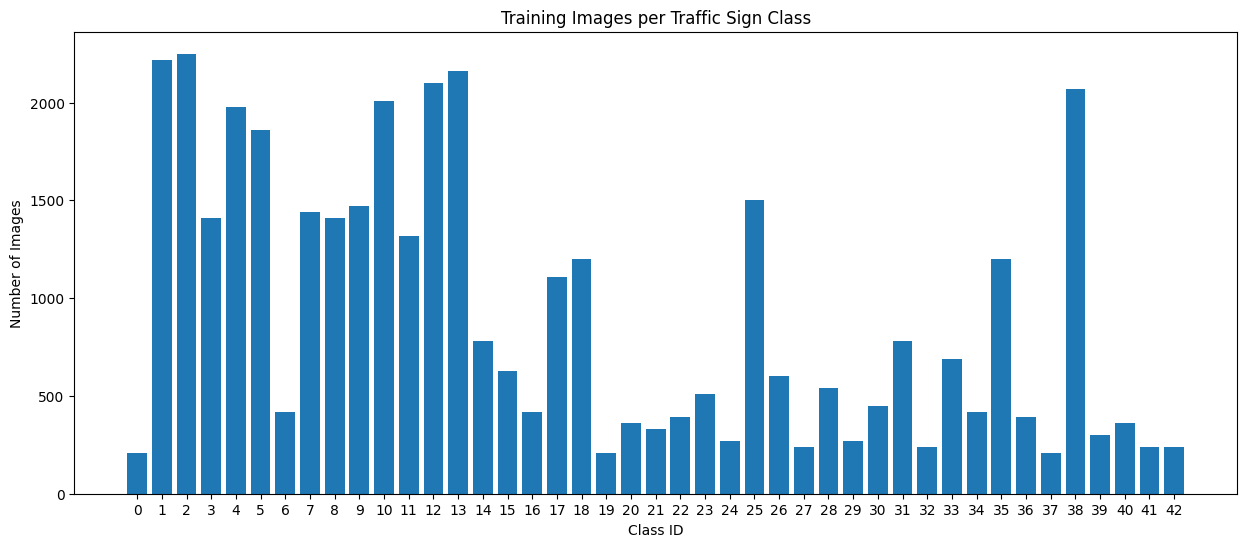

In [12]:
import os
import matplotlib.pyplot as plt

class_counts = []

for class_id in range(43):
    class_path = os.path.join(TRAIN_DIR, str(class_id))
    count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])
    class_counts.append(count)

plt.figure(figsize=(15, 6))
plt.bar(range(43), class_counts)

plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.title("Training Images per Traffic Sign Class")
plt.xticks(range(43))

plt.show()

In [13]:
meta_df = pd.read_csv("/content/data/Meta.csv")

print(meta_df.head())
print("\nColumns:")
print(meta_df.columns.tolist())


          Path  ClassId  ShapeId  ColorId SignId
0  Meta/27.png       27        0        0   1.32
1   Meta/0.png        0        1        0   3.29
2   Meta/1.png        1        1        0   3.29
3  Meta/10.png       10        1        0   3.27
4  Meta/11.png       11        0        0   1.22

Columns:
['Path', 'ClassId', 'ShapeId', 'ColorId', 'SignId']


In [14]:
import os
import pandas as pd

TRAIN_DIR = "/content/data/Train"

image_paths = []
labels = []

for class_id in range(43):
    class_dir = os.path.join(TRAIN_DIR, str(class_id))

    for filename in os.listdir(class_dir):
        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(class_dir, filename))
            labels.append(class_id)

data_df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total images:", len(data_df))
print(data_df.head())

Total images: 39209
                                    image_path  label
0  /content/data/Train/0/00000_00003_00010.png      0
1  /content/data/Train/0/00000_00002_00001.png      0
2  /content/data/Train/0/00000_00004_00008.png      0
3  /content/data/Train/0/00000_00005_00027.png      0
4  /content/data/Train/0/00000_00001_00019.png      0


In [15]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    data_df,
    test_size=0.20,
    stratify=data_df["label"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

Training images: 31367
Validation images: 7842


In [16]:
import tensorflow as tf

IMG_SIZE = (48, 48)
BATCH_SIZE = 32

def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label

In [17]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values, train_df["label"].values)
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.shuffle(
    buffer_size=len(train_df),
    seed=42
)

train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

In [18]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].values, val_df["label"].values)
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [19]:
images, labels = next(iter(train_ds))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Pixel range:", images.numpy().min(), "to", images.numpy().max())
print("Labels:", labels[:10].numpy())

Images shape: (32, 48, 48, 3)
Labels shape: (32,)
Pixel range: 3.0104275 to 255.0
Labels: [ 6  8 10 33 14  8 14  2 31  8]


In [20]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])
normalization = layers.Rescaling(1./255)

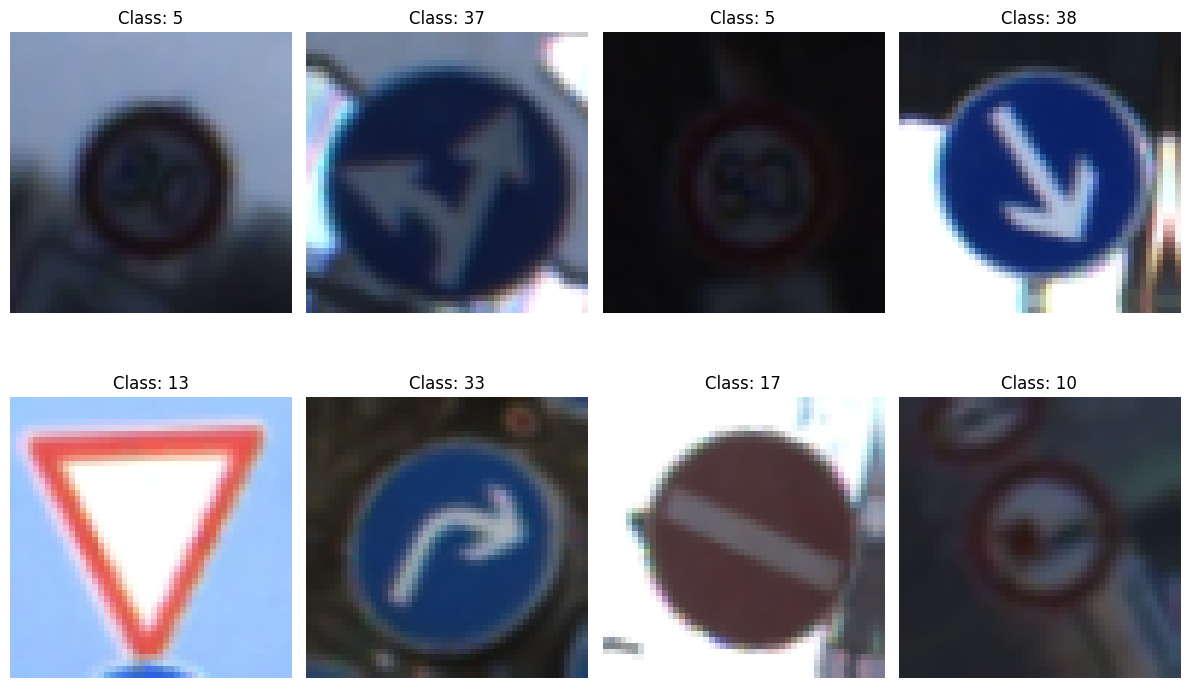

In [21]:
import matplotlib.pyplot as plt

sample_images, sample_labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for i in range(8):
    augmented_image = data_augmentation(sample_images[i:i+1], training=True)

    plt.subplot(2, 4, i + 1)
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.title(f"Class: {sample_labels[i].numpy()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(48, 48, 3)),

    data_augmentation,
    normalization,

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(43, activation="softmax")
])

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,067 (1.38 MB)

 Trainable params: 361,067 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_traffic_sign_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [26]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_df["label"])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = dict(
    zip(classes, class_weights_array)
)

print(class_weights)

{np.int64(0): np.float64(4.342054263565892), np.int64(1): np.float64(0.41073486276974647), np.int64(2): np.float64(0.40525839793281654), np.int64(3): np.float64(0.6466889328715157), np.int64(4): np.float64(0.460520906741837), np.int64(5): np.float64(0.4902319329832458), np.int64(6): np.float64(2.171027131782946), np.int64(7): np.float64(0.6332162467700259), np.int64(8): np.float64(0.6466889328715157), np.int64(9): np.float64(0.6202934662236987), np.int64(10): np.float64(0.4536474603725558), np.int64(11): np.float64(0.6907813601127555), np.int64(12): np.float64(0.43420542635658915), np.int64(13): np.float64(0.4221441645133506), np.int64(14): np.float64(1.169014609421586), np.int64(15): np.float64(1.4473514211886305), np.int64(16): np.float64(2.171027131782946), np.int64(17): np.float64(0.8214697255394929), np.int64(18): np.float64(0.759859496124031), np.int64(19): np.float64(4.342054263565892), np.int64(20): np.float64(2.5328649870801034), np.int64(21): np.float64(2.763125440451022), np

In [27]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.2759 - loss: 2.5094 - val_accuracy: 0.6131 - val_loss: 1.2322
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.5607 - loss: 1.2324 - val_accuracy: 0.7872 - val_loss: 0.6659
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.6857 - loss: 0.8208 - val_accuracy: 0.8866 - val_loss: 0.3825
Epoch 4/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.7632 - loss: 0.5993 - val_accuracy: 0.8812 - val_loss: 0.3491
Epoch 5/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8197 - loss: 0.4532 - val_accuracy: 0.9438 - val_loss: 0.1956
Epoch 6/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8549 - loss: 0.3561 - val_accuracy: 0.9679 - val_loss: 0.1254
Epoch 7/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8829 - loss: 0.2946 - val_accuracy: 0.9740 - val_loss: 0.0972
Epoch 8/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8976 - loss: 0.2729 - 

In [28]:
model.save("traffic_sign_model.keras")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

X_test_norm = X_test.astype("float32")  
y_pred_probs = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=range(43), yticklabels=range(43))
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Traffic Sign Classification")
plt.show()

test_loss, test_acc = model.evaluate(X_test_norm, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")